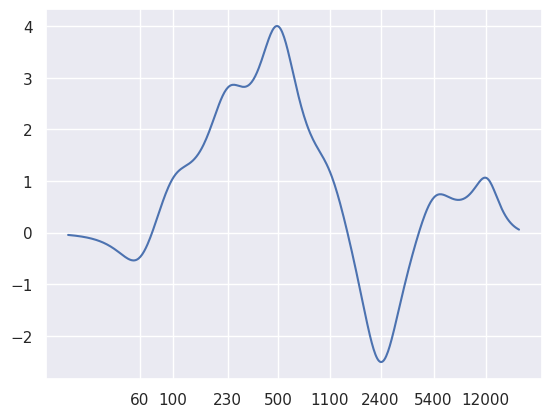

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme()

# === Configuration: 8-Band Parametric EQ Parameters ===
# Each band: (frequency_hz, gain_db, q_factor)
q = 1.2
bands = [
    {"freq": 60, "gain_db": -1, "Q": q},
    {"freq": 100, "gain_db": 1, "Q": q},
    {"freq": 230, "gain_db": 2, "Q": q},
    {"freq": 500, "gain_db": 3.5, "Q": q},
    {"freq": 1100, "gain_db": 1, "Q": q},
    {"freq": 2400, "gain_db": -3, "Q": q},
    {"freq": 5400, "gain_db": 1, "Q": q},
    {"freq": 12000, "gain_db": 1, "Q": q},
]

sample_rate = 48000  # Hz

# === Compute frequency response ===
# Logarithmically spaced frequencies from 20 Hz to 20 kHz
num_points = 500
freqs = np.logspace(np.log10(20), np.log10(20000), num_points)

# Combined magnitude response in dB
total_response_db = np.zeros(num_points)

for band in bands:
    f0 = band["freq"]
    gain_db = band["gain_db"]
    Q = band["Q"]

    if gain_db == 0.0:
        continue

    # Peaking EQ filter coefficients (Audio EQ Cookbook - Robert Bristow-Johnson)
    A = 10 ** (gain_db / 40.0)
    w0 = 2 * np.pi * f0 / sample_rate
    alpha = np.sin(w0) / (2 * Q)

    b0 = 1 + alpha * A
    b1 = -2 * np.cos(w0)
    b2 = 1 - alpha * A
    a0 = 1 + alpha / A
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha / A

    # Normalize
    b0 /= a0
    b1 /= a0
    b2 /= a0
    a1 /= a0
    a2 /= a0

    # Evaluate H(e^jw) at each frequency
    w = 2 * np.pi * freqs / sample_rate
    ejw = np.exp(1j * w)
    ejw2 = np.exp(2j * w)

    H = (b0 + b1 * ejw**-1 + b2 * ejw2**-1) / (1 + a1 * ejw**-1 + a2 * ejw2**-1)
    total_response_db += 20 * np.log10(np.abs(H))

sns.lineplot(x=freqs, y=total_response_db)
plt.xscale("log")
plt.xticks([60, 100, 230, 500, 1100, 2400, 5400, 12000], [str(band["freq"]) for band in bands])
plt.show()

In [15]:
coeff = 1
print("frequency,raw")
for band in bands:
    print(f"{band['freq']},{band['gain_db'] * coeff}")

frequency,raw
60,-1
100,1
230,2
500,3.5
1100,1
2400,-3
5400,1
12000,1
